In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [17]:
X, y = make_blobs(n_samples=500, centers=3, cluster_std=0.60,random_state=42)

In [18]:
df = pd.DataFrame(X,columns = [ 'Feature 1' , 'Feature 2'])



In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [20]:
inertia = [] #also known as wcss
k_range = range(1,11)

In [21]:
for k in k_range:
    kmeans = KMeans(n_clusters = k , random_state = 42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [22]:
inertia

[1000.0,
 297.8954141051722,
 11.575484723104982,
 9.752067977356841,
 8.25717527244628,
 6.917577320416799,
 6.334755391595288,
 5.70417717790143,
 5.060234133532076,
 4.762361898130396]

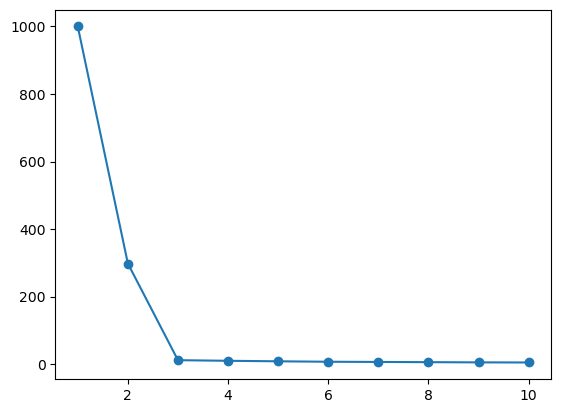

In [23]:
plt.plot(k_range,inertia,marker='o')

In [24]:
kmeans_final = KMeans(n_clusters = 3 , random_state = 42)

In [25]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [26]:
df['cluster'] = cluster_labels

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

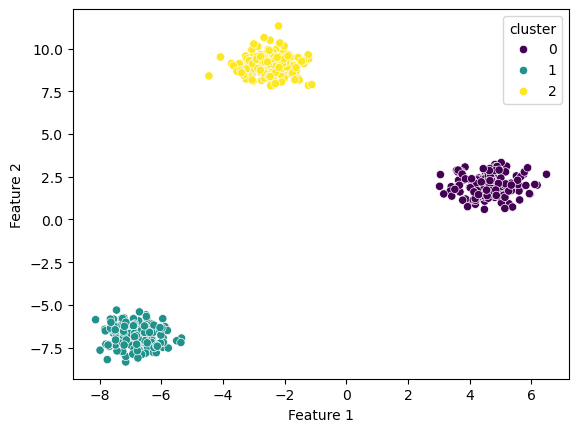

In [27]:
sns.scatterplot(x=df['Feature 1'],y= df['Feature 2'],hue = df['cluster'],palette = 'viridis')

In [28]:
from sklearn.datasets import make_moons

In [29]:
X1, y1 = make_moons(n_samples=500, noise=0.05, random_state=42)

In [30]:
from sklearn.cluster import KMeans , DBSCAN

In [32]:
df = pd.DataFrame(X1,columns = ['Feature 1','Feature 2'])

In [33]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

In [34]:
kmeans =KMeans(n_clusters =2 , random_state =42)
kmeans_label = kmeans.fit_predict(x_scaled)

In [35]:
df['kmeans_clusters'] = kmeans_label

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

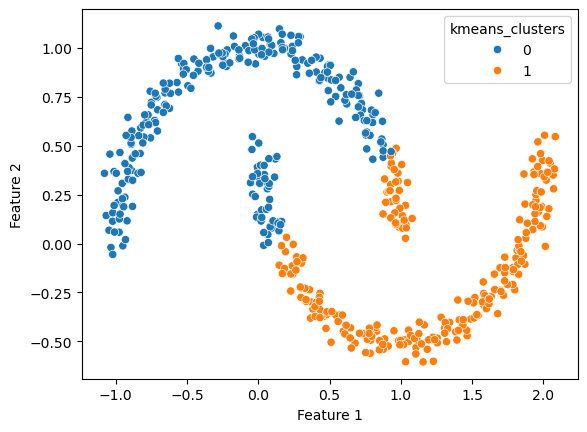

In [37]:
sns.scatterplot(x=df['Feature 1'],y= df['Feature 2'],hue = df['kmeans_clusters'],palette = 'tab10')

In [40]:

dbscan = DBSCAN(eps = 0.3 , min_samples =5)
dbscan_labels = dbscan.fit_predict(x_scaled)

In [41]:
df['dbscan_cluster'] = dbscan_labels

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

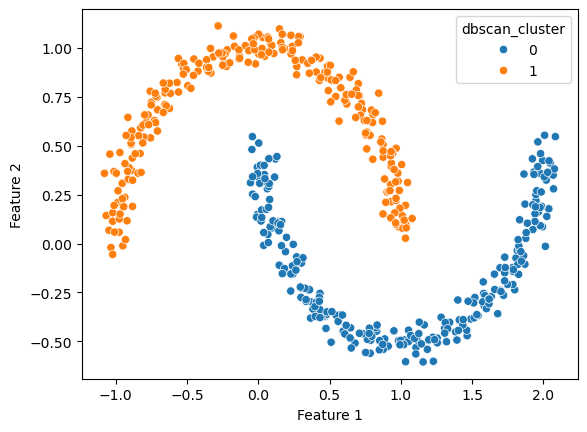

In [43]:
sns.scatterplot(x=df['Feature 1'],y= df['Feature 2'],hue = df['dbscan_cluster'],palette = 'tab10')